# **Reinforcement Learning**

In [47]:
import gymnasium as gym
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
env = gym.make("FrozenLake-v1", render_mode="ansi")
# number of states = 16, number of actions = 4
observe_env, info_env = env.reset() #reset to starting state
action = env.action_space.sample() #Get a random action
new_state, reward, terminated, truncated, info = env.step(action)
#After Action, new state, reward from action, ..., probability of action
done = terminated or truncated # is game done (if True, reset)
print(env.render()) #Render gui

  (Left)
SFFF
FHFH
FFFH
HFFG



Building Q-Table

In [49]:
import gymnasium as gym
import numpy as np
import time
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
env = gym.make("FrozenLake-v1", render_mode="ansi")
STATES = env.observation_space.n
ACTIONS = env.action_space.n
Q = np.zeros((STATES, ACTIONS)) #16x4 Q-table
EPISODES = 2000 # times to run the enviroment from the beginning
MAX_STEPS = 100 # max steps allows for each run
LEARNING_RATE = 0.81 #a Higher rate means more change in table
GAMMA = 0.96 #y
RENDER = False #show gui
#Pick an action
epsilon = 0.9 #90% chance of doing a random action
rewards = [] #store rewards
for episode in range(EPISODES):
    state, info = env.reset()
    for step in range(MAX_STEPS):
        if RENDER:
            env.render()
            time.sleep(0.1)

        if np.random.uniform(0, 1) < epsilon:
            action = env.action_space.sample() # Take random action
        else:
            action = np.argmax(Q[state, :]) # Use Q table to pick action
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        # Learning Q-Table
        Q[state, action] = Q[state, action] + LEARNING_RATE * (reward + GAMMA * np.max(Q[new_state, :]) - Q[state, action])
        state = new_state
        if done:
          rewards.append(reward)
          epsilon -= 0.001
          break #reached goal
print(Q)
print(f"Average reward: {sum(rewards)/len(rewards)}:")

[[3.41203701e-01 2.45798002e-02 2.34522620e-02 2.68422099e-02]
 [1.53298348e-02 7.62186637e-03 1.77887969e-02 2.45484083e-01]
 [1.39195815e-02 9.94522697e-03 9.12997335e-03 2.17237042e-01]
 [5.22256889e-03 5.53233817e-03 1.16598367e-02 1.26369153e-01]
 [5.80283738e-01 1.19582602e-02 1.95011457e-02 9.89323703e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [2.40298636e-01 2.85360119e-05 8.59877492e-05 1.03452399e-07]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.13598571e-02 9.23737485e-03 3.45883365e-03 3.43004068e-01]
 [9.33215233e-03 5.03468062e-01 1.71029363e-02 1.74524568e-02]
 [1.38140622e-01 1.77178560e-03 1.01997238e-03 3.01268331e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [8.66016790e-02 5.15823699e-03 8.73967823e-01 3.78051045e-02]
 [1.19828306e-01 9.93270001e-01 1.62502588e-01 1.10065994e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.000000

Plot Reward

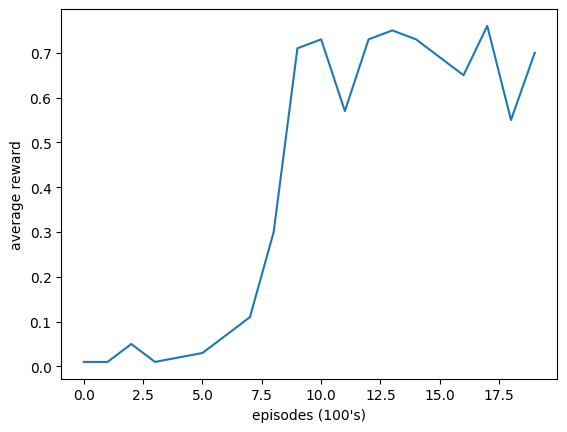

In [50]:
# we can plot the training progress and see how the agent improved
import matplotlib.pyplot as plt

def get_average(values):
  return sum(values)/len(values)

avg_rewards = []
for i in range(0, len(rewards), 100):
  avg_rewards.append(get_average(rewards[i:i+100]))

plt.plot(avg_rewards)
plt.ylabel('average reward')
plt.xlabel('episodes (100\'s)')
plt.show()